# 18: End-to-End DoubleML Case Study

This lesson closes the DoubleML tutorial series with a full case study. A complete DoubleML analysis should read from start to finish: causal question, estimand, data roles, estimator choice, learners, diagnostics, uncertainty, sensitivity checks, subgroup exploration, and a short final report.

The case study asks a generic product analytics question:

> What is the causal effect of receiving a guided onboarding nudge on next-period user value?

The treatment is binary: a user either receives the nudge or does not. The outcome is continuous: a next-period value index. Because treatment is observational rather than randomized, treated and untreated users differ in baseline intent, engagement, tenure, support needs, and other pre-treatment signals.

The target estimand is the average treatment effect:

$$
\theta_0 = \mathbb{E}\left[Y(1) - Y(0)\right],
$$

where $Y(1)$ is the potential outcome if a user receives the nudge and $Y(0)$ is the potential outcome if the same user does not. Identification requires the usual observational assumptions:

$$
\left(Y(1), Y(0)\right) \perp D \mid X,
$$

$$
0 < \mathbb{P}(D = 1 \mid X) < 1,
$$

and stable measurement of treatment, outcome, and controls. The first condition says the observed pre-treatment controls $X$ are sufficient for adjustment. The second says treated and untreated users overlap at comparable covariate values.

For a binary treatment, DoubleML's interactive regression model estimates two outcome nuisance functions and one propensity nuisance function:

$$
g_0(0, X) = \mathbb{E}[Y \mid D = 0, X],
\qquad
 g_0(1, X) = \mathbb{E}[Y \mid D = 1, X],
$$

$$
m_0(X) = \mathbb{P}(D = 1 \mid X).
$$

The doubly robust score for the ATE can be written as:

$$
\phi_i = \hat{g}(1, X_i) - \hat{g}(0, X_i)
+ \frac{D_i\left(Y_i - \hat{g}(1, X_i)\right)}{\hat{m}(X_i)}
- \frac{(1-D_i)\left(Y_i - \hat{g}(0, X_i)\right)}{1-\hat{m}(X_i)}.
$$

The estimate is the average of this orthogonal signal:

$$
\hat{\theta} = \frac{1}{n}\sum_{i=1}^{n}\phi_i.
$$

The strength of this workflow is not that it makes observational data magically causal. Its strength is that it gives us a principled estimate after we have made the design assumptions explicit and checked the numerical risks.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **End-To-End DoubleML Case Study**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the notebook separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The experiment is closer to a complete applied analysis. Question framing, design, estimation, diagnostics, and reporting are meant to be read together.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.


## Mathematical Foundation

<!-- math-foundation-note -->

Advanced DoubleML workflows still revolve around orthogonal scores. A custom score is valid only when

$$
\mathbb{E}\{\psi(W;\theta_0,\eta_0)\}=0, \qquad
\left.\partial_{\eta}\mathbb{E}\{\psi(W;\theta_0,\eta)\}\right|_{\eta=\eta_0}=0.
$$

Every estimate should be connected back to its score, nuisance functions, sample splitting, and identifying assumptions.





## Tutorial Workflow

#### Setup

This setup cell imports the full case-study stack and creates the shared tutorial output folders. The repository-root detection keeps paths correct whether the notebook is executed from the repo root or directly from the notebook directory.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate pyproject.toml; run this lesson from inside the repository.")

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MPLCONFIG_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MPLCONFIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ["MPLCONFIGDIR"] = str(MPLCONFIG_DIR)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="The estimated nu2 .*", category=UserWarning)

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
import doubleml as dml
from doubleml.utils.propensity_score_processing import PSProcessorConfig

from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from scipy.special import expit
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="talk")

RANDOM_SEED = 1818
NOTEBOOK_PREFIX = "18"
TRUE_TARGET_NAME = "true_ate"

print(f"DoubleML version: {dml.__version__}")
print(f"Writing artifacts under: {OUTPUT_DIR}")


DoubleML version: 0.11.2
Writing artifacts under: /home/apex/Documents/portfolio/notebooks/tutorials/doubleml/outputs


The setup prints the DoubleML version and output root. Every generated file uses prefix `18`, which makes the final generated files easy to audit.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### Helper Functions

The helper functions below are deliberately practical. A real analysis usually repeats the same actions many times: saving tables, fitting a model, extracting predictions, computing overlap diagnostics, building a doubly robust signal, and producing a compact estimate row.

In [2]:
# Define reusable helpers for the Helper Functions section.
def save_table(df, filename):
    """
    Idea: Save a result table to the notebook table directory and return the same DataFrame for display.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    filename : str
        Output filename used inside the tutorial artifact directory.
    
    Returns
    -------
    pd.DataFrame
        Same table after writing it to the tutorial table directory.
    """
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return path


def save_dataset(df, filename):
    """
    Idea: Write the constructed dataset to the tutorial output folder so later notebooks or cells can reuse it.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    filename : str
        Output filename used inside the tutorial artifact directory.
    
    Returns
    -------
    pd.DataFrame
        Same dataset after writing it to the tutorial dataset directory.
    """
    path = DATASET_DIR / filename
    df.to_csv(path, index=False)
    return path


def rmse(y_true, y_pred):
    """
    Idea: Compute root mean squared error between an oracle target and an estimated or predicted value.
    
    Parameters
    ----------
    y_true : array-like
        Reference outcome, oracle value, or known target used for evaluation.
    y_pred : array-like
        Predicted outcome or estimated value being evaluated.
    
    Returns
    -------
    float
        Root mean squared error between the reference values and predictions.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def make_kfold_splits(n_obs, seed, n_splits=5):
    """
    Idea: Construct the K-fold splits used in the Helper Functions section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n_obs : int
        Number of observations generated for the experiment.
    seed : int
        Random seed used to make generation or resampling reproducible.
    n_splits : object
        Number of folds or sample splits used for cross-fitting.
    
    Returns
    -------
    list[tuple[np.ndarray, np.ndarray]]
        Train-test fold index pairs for cross-fitting.
    """
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return [(train_idx, test_idx) for train_idx, test_idx in kfold.split(np.arange(n_obs))]


def extract_prediction(model, learner_name):
    """
    Idea: Pull a prediction vector from a fitted learner while handling learners that return two-dimensional arrays.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by the diagnostic.
    learner_name : object
        Readable name for the learner configuration being reported.
    
    Returns
    -------
    np.ndarray
        Flattened prediction vector extracted from stored DoubleML nuisance predictions.
    """
    return model.predictions[learner_name][:, 0, 0]


def fit_irm(df, x_cols, learner_g, learner_m, label, sample_splits=None, n_folds=5):
    """
    Idea: Fit the interactive regression model model and return the fitted object or summary needed for interpretation.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    x_cols : list[str]
        Covariate column names used as model inputs.
    learner_g : object
        Outcome-regression learner used by the DoubleML score.
    learner_m : object
        Treatment or propensity learner used as a nuisance model.
    label : str
        Short label attached to a scenario, method, or plotted result.
    sample_splits : object
        Fold assignments used to keep nuisance fitting separate from score evaluation.
    n_folds : int
        Number of folds used for cross-fitting or validation.
    
    Returns
    -------
    tuple[DoubleMLIRM, dict, dict]
        Fitted IRM model, summary row, and stored nuisance predictions.
    """
    data = dml.DoubleMLData(df, y_col="next_period_value", d_cols="onboarding_nudge", x_cols=x_cols)
    ps_config = PSProcessorConfig(clipping_threshold=0.02)
    model = dml.DoubleMLIRM(
        data,
        ml_g=clone(learner_g),
        ml_m=clone(learner_m),
        n_folds=n_folds,
        score="ATE",
        normalize_ipw=True,
        ps_processor_config=ps_config,
    )

    if sample_splits is not None:
        model.set_sample_splitting(sample_splits)

    model.fit(store_predictions=True)
    ci = model.confint(level=0.95).iloc[0]
    losses = model.evaluate_learners()

    e_hat = np.clip(extract_prediction(model, "ml_m"), 0.02, 0.98)
    mu0_hat = extract_prediction(model, "ml_g0")
    mu1_hat = extract_prediction(model, "ml_g1")

    row = {
        "model": label,
        "estimate": float(model.coef[0]),
        "std_error": float(model.se[0]),
        "ci_95_lower": float(ci["2.5 %"]),
        "ci_95_upper": float(ci["97.5 %"]),
        "true_ate": float(df["true_treatment_effect"].mean()),
        "absolute_error": abs(float(model.coef[0]) - float(df["true_treatment_effect"].mean())),
        "ml_g0_rmse": float(losses["ml_g0"][0][0]),
        "ml_g1_rmse": float(losses["ml_g1"][0][0]),
        "ml_m_log_loss": float(losses["ml_m"][0][0]),
        "propensity_min": float(e_hat.min()),
        "propensity_p05": float(np.quantile(e_hat, 0.05)),
        "propensity_median": float(np.median(e_hat)),
        "propensity_p95": float(np.quantile(e_hat, 0.95)),
        "propensity_max": float(e_hat.max()),
    }
    predictions = pd.DataFrame(
        {
            "mu0_hat": mu0_hat,
            "mu1_hat": mu1_hat,
            "propensity_hat": e_hat,
        },
        index=df.index,
    )
    return model, row, predictions


def doubly_robust_signal(df, predictions):
    """
    Idea: Construct the doubly robust pseudo-outcome used to estimate a causal effect with nuisance models.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    predictions : object
        Predicted values returned by the fitted learner.
    
    Returns
    -------
    np.ndarray
        Doubly robust pseudo-outcome values, one per observation.
    """
    y = df["next_period_value"].to_numpy()
    d = df["onboarding_nudge"].to_numpy()
    mu0 = predictions["mu0_hat"].to_numpy()
    mu1 = predictions["mu1_hat"].to_numpy()
    e = np.clip(predictions["propensity_hat"].to_numpy(), 0.02, 0.98)
    signal = mu1 - mu0 + d * (y - mu1) / e - (1 - d) * (y - mu0) / (1 - e)
    return signal


These helpers do not hide the analysis. They standardize repeated mechanical work so the notebook can focus on design choices and diagnostics. The `doubly_robust_signal()` helper mirrors the ATE score described in the introduction.

### Case Study Roadmap

The roadmap table turns the rest of the notebook into a review checklist. End-to-end causal work should be readable in this order: design first, estimation second, diagnostics third, reporting last.

| stage | main_question |
| --- | --- |
| Causal question | What treatment, outcome, population, and estimand are we studying? |
| Data design | Which variables are pre-treatment controls, treatment, outcome, and invalid post-treatment signals? |
| Estimator choice | Why is IRM appropriate for a binary treatment? |
| Main estimate | What does DoubleML estimate after cross-fitting nuisance functions? |
| Diagnostics | Do propensity scores overlap, do nuisance models behave plausibly, and are results split-stable? |
| Heterogeneity | Which user segments appear to benefit more, and how should that be reported cautiously? |
| Sensitivity | How strong would hidden confounding need to be to threaten the conclusion? |
| Report | What evidence, assumptions, and limitations should a reader see? |


The roadmap gives the notebook a story. The key habit is that the causal question and variable timing come before model fitting.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


#### Simulate the Case Study Data

We simulate data with known truth so students can see when the workflow succeeds and where it remains vulnerable. The observed controls are all measured before treatment. The treatment is `onboarding_nudge`, and the outcome is `next_period_value`.

Treatment assignment is observational:

$$
D_i \sim \text{Bernoulli}(m_0(X_i)).
$$

The outcome is generated from baseline value plus a heterogeneous treatment effect:

$$
Y_i = b_0(X_i) + \tau(X_i)D_i + \varepsilon_i.
$$

The true ATE is:

$$
\theta_0 = \mathbb{E}[\tau(X_i)].
$$

A real case study would not know $\tau(X_i)$ or $m_0(X_i)$. Here they are retained only for learning and validation.

In [3]:
# Save the artifacts produced by the Simulate The Case Study Data section.
rng = np.random.default_rng(RANDOM_SEED)
n_obs = 3_200

engagement_score = rng.normal(0, 1, n_obs)
intent_score = rng.normal(0, 1, n_obs)
content_breadth = rng.normal(0, 1, n_obs)
price_sensitivity = rng.normal(0, 1, n_obs)
mobile_share = rng.beta(4, 3, n_obs)
weekend_share = rng.beta(3, 5, n_obs)
account_age_weeks = rng.gamma(shape=2.4, scale=8.0, size=n_obs)
new_user = (account_age_weeks < np.quantile(account_age_weeks, 0.30)).astype(int)
email_opt_in = rng.binomial(1, expit(0.25 + 0.4 * engagement_score - 0.2 * price_sensitivity), n_obs)
support_contacts = rng.poisson(np.exp(-0.2 + 0.25 * price_sensitivity - 0.20 * engagement_score))

propensity_logit = (
    -0.35
    + 0.65 * intent_score
    + 0.35 * new_user
    + 0.30 * email_opt_in
    - 0.35 * price_sensitivity
    + 0.18 * mobile_share
    - 0.12 * support_contacts
    + 0.10 * content_breadth
)
true_propensity = np.clip(expit(propensity_logit), 0.05, 0.95)
onboarding_nudge = rng.binomial(1, true_propensity, n_obs)

true_treatment_effect = (
    0.34
    + 0.14 * intent_score
    + 0.11 * new_user
    - 0.06 * price_sensitivity
    + 0.05 * email_opt_in
    + 0.04 * mobile_share
)

baseline_value = (
    2.20
    + 0.70 * engagement_score
    + 0.45 * intent_score
    + 0.25 * content_breadth
    + 0.12 * np.sqrt(account_age_weeks)
    - 0.30 * price_sensitivity
    - 0.20 * support_contacts
    + 0.25 * email_opt_in
    + 0.10 * np.sin(2 * np.pi * weekend_share)
)

next_period_value = baseline_value + true_treatment_effect * onboarding_nudge + rng.normal(0, 0.90, n_obs)

# This intentionally invalid variable is created after treatment and outcome realization.
post_treatment_activity_proxy = 0.45 * next_period_value + 0.25 * onboarding_nudge + rng.normal(0, 0.55, n_obs)

case_df = pd.DataFrame(
    {
        "engagement_score": engagement_score,
        "intent_score": intent_score,
        "content_breadth": content_breadth,
        "price_sensitivity": price_sensitivity,
        "mobile_share": mobile_share,
        "weekend_share": weekend_share,
        "account_age_weeks": account_age_weeks,
        "new_user": new_user,
        "email_opt_in": email_opt_in,
        "support_contacts": support_contacts,
        "onboarding_nudge": onboarding_nudge,
        "next_period_value": next_period_value,
        "post_treatment_activity_proxy": post_treatment_activity_proxy,
        "true_propensity": true_propensity,
        "true_treatment_effect": true_treatment_effect,
    }
)

case_df["intent_segment"] = pd.qcut(
    case_df["intent_score"],
    q=3,
    labels=["low_intent", "mid_intent", "high_intent"],
)

x_cols = [
    "engagement_score",
    "intent_score",
    "content_breadth",
    "price_sensitivity",
    "mobile_share",
    "weekend_share",
    "account_age_weeks",
    "new_user",
    "email_opt_in",
    "support_contacts",
]

save_dataset(case_df, f"{NOTEBOOK_PREFIX}_end_to_end_case_study_data.csv")
case_df.head()


,engagement_score,intent_score,content_breadth,price_sensitivity,mobile_share,weekend_share,account_age_weeks,new_user,email_opt_in,support_contacts,onboarding_nudge,next_period_value,post_treatment_activity_proxy,true_propensity,true_treatment_effect,intent_segment
0,0.694589,-0.187952,1.302988,-0.089980,0.599224,0.547231,16.345623,0,0,1,0,3.805909,1.461115,0.420063,0.343054,mid_intent
1,0.589058,0.868203,-0.995821,0.703798,0.721945,0.301545,15.095610,0,0,0,1,3.430184,2.047801,0.499593,0.448198,high_intent
2,0.838012,0.042641,0.390679,2.390325,0.602758,0.326320,7.513168,1,0,2,0,1.888274,0.165999,0.288777,0.336661,mid_intent
3,1.556491,1.146182,-0.830658,0.484532,0.656579,0.772629,8.053153,1,1,0,0,2.979645,1.295039,0.713113,0.657657,high_intent
4,-1.094204,-2.179274,-1.406732,-0.702787,0.434521,0.303187,13.355840,0,1,0,0,0.308343,0.135570,0.217038,0.144450,low_intent


The first rows include the teaching-only columns `true_propensity` and `true_treatment_effect`. Those columns are not included in the DoubleML feature set. They are kept so we can compare the estimated ATE to the known truth.

#### Field Dictionary

This field dictionary documents the timing and role of every column. In an observational analysis, this table is not decorative. It is the difference between valid adjustment and accidental leakage.

| field | role | used_in_model | description |
| --- | --- | --- | --- |
| engagement_score | pre-treatment control | True | Baseline engagement before nudge eligibility. |
| intent_score | pre-treatment control | True | Baseline intent or product-fit signal. |
| content_breadth | pre-treatment control | True | Breadth of prior usage across app areas. |
| price_sensitivity | pre-treatment control | True | Baseline sensitivity or friction signal. |
| mobile_share | pre-treatment control | True | Share of prior activity on mobile. |
| weekend_share | pre-treatment control | True | Share of prior activity occurring on weekends. |
| account_age_weeks | pre-treatment control | True | Tenure before treatment eligibility. |
| new_user | pre-treatment control | True | Indicator derived from account age. |
| email_opt_in | pre-treatment control | True | Baseline communication eligibility. |
| support_contacts | pre-treatment control | True | Prior support-contact count. |
| onboarding_nudge | treatment | treatment column | Binary exposure to the guided onboarding nudge. |
| next_period_value | outcome | outcome column | Continuous value index after treatment. |
| intent_segment | reporting segment | False | Segment used for subgroup summaries. |
| post_treatment_activity_proxy | post-treatment leakage | False | Invalid control retained only as a warning example. |
| true_propensity | oracle teaching column | False | Known treatment probability from simulation. |
| true_treatment_effect | oracle teaching column | False | Known individual treatment effect from simulation. |


The feature set includes only pre-treatment controls. The post-treatment proxy is intentionally excluded. A real case study should include this kind of timing table before any model results.




## Diagnostics and Interpretation

### Data Audit

The data audit checks sample size, treatment rate, outcome scale, known true ATE, and propensity overlap from the simulator. In a real observational dataset, the oracle columns would be unavailable. The same audit structure still applies.

In [4]:
data_audit = pd.DataFrame(
    [
        {"metric": "rows", "value": len(case_df)},
        {"metric": "treatment_rate", "value": case_df["onboarding_nudge"].mean()},
        {"metric": "outcome_mean", "value": case_df["next_period_value"].mean()},
        {"metric": "outcome_sd", "value": case_df["next_period_value"].std()},
        {"metric": "true_ate", "value": case_df["true_treatment_effect"].mean()},
        {"metric": "true_propensity_p05", "value": case_df["true_propensity"].quantile(0.05)},
        {"metric": "true_propensity_p95", "value": case_df["true_propensity"].quantile(0.95)},
        {"metric": "pre_treatment_controls", "value": len(x_cols)},
    ]
)

save_table(data_audit, f"{NOTEBOOK_PREFIX}_data_audit.csv")
display(data_audit)


,metric,value
0,rows,3200.000000
1,treatment_rate,0.463125
2,outcome_mean,2.917136
3,outcome_sd,1.451041
4,true_ate,0.425708
5,true_propensity_p05,0.202593
6,true_propensity_p95,0.777225
7,pre_treatment_controls,10.000000


The treatment rate and propensity quantiles suggest there is meaningful treated and untreated support. This does not prove overlap after flexible estimation, so we will inspect estimated propensities later.



### Design Diagram

The diagram below now focuses only on the causal design. The nuisance models used by DoubleML are introduced later in the estimation section. Keeping the graph causal makes the arrows easier to read: baseline controls affect both nudge assignment and future value, the nudge affects future value, baseline profile can modify the treatment effect, and dashed arrows mark unmeasured-confounding risk.

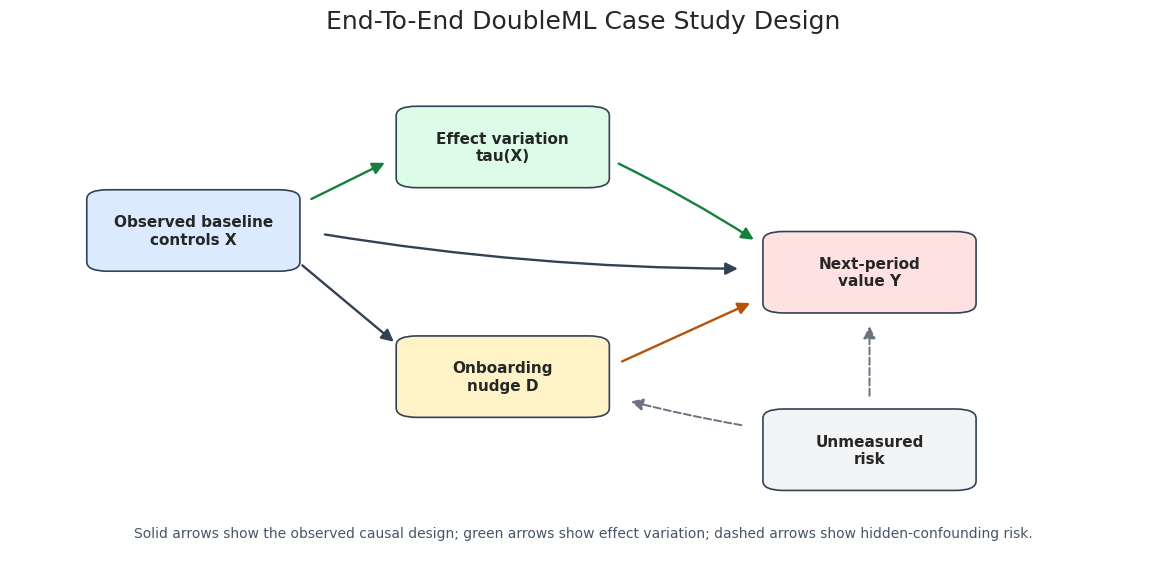

In [5]:
nodes = {
    "X": {"xy": (0.16, 0.66), "label": "Observed baseline\ncontrols X", "color": "#dbeafe"},
    "T": {"xy": (0.43, 0.82), "label": "Effect variation\ntau(X)", "color": "#dcfce7"},
    "D": {"xy": (0.43, 0.38), "label": "Onboarding\nnudge D", "color": "#fef3c7"},
    "Y": {"xy": (0.75, 0.58), "label": "Next-period\nvalue Y", "color": "#fee2e2"},
    "U": {"xy": (0.75, 0.24), "label": "Unmeasured\nrisk", "color": "#f3f4f6"},
}

fig, ax = plt.subplots(figsize=(12, 6.2))
ax.set_axis_off()
ax.set_xlim(0.00, 1.00)
ax.set_ylim(0.00, 1.00)
box_w, box_h = 0.15, 0.12


def anchor(node, side):
    """
    Idea: Return the plotting anchor point for a named node in the diagram.
    
    Parameters
    ----------
    node : object
        Graph node whose position, label, or incident edges are being processed.
    side : object
        Endpoint side used to place an arrow or edge on the correct part of a node.
    
    Returns
    -------
    tuple[float, float] or np.ndarray
        Coordinate of the requested side of a plotted node.
    """
    x, y = nodes[node]["xy"]
    offsets = {
        "left": (-box_w / 2, 0),
        "right": (box_w / 2, 0),
        "top": (0, box_h / 2),
        "bottom": (0, -box_h / 2),
        "upper_right": (box_w / 2, box_h * 0.25),
        "lower_right": (box_w / 2, -box_h * 0.25),
        "upper_left": (-box_w / 2, box_h * 0.25),
        "lower_left": (-box_w / 2, -box_h * 0.25),
    }
    dx, dy = offsets[side]
    return np.array([x + dx, y + dy], dtype=float)


def shorten(start, end, gap=0.038):
    """
    Idea: Shorten a line segment so the arrowhead remains visible outside the node box.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    gap : float
        Spacing used to keep plotted elements from overlapping.
    
    Returns
    -------
    tuple[float, float]
        Shortened endpoint coordinate that keeps an arrowhead visible.
    """
    start = np.asarray(start, dtype=float)
    end = np.asarray(end, dtype=float)
    delta = end - start
    length = np.hypot(delta[0], delta[1])
    if length == 0:
        return tuple(start), tuple(end)
    unit = delta / length
    return tuple(start + gap * unit), tuple(end - gap * unit)


def draw_arrow(start, end, color="#334155", style="solid", rad=0.0, linewidth=1.7):
    """
    Idea: Draw a routed arrow between diagram nodes while keeping the arrowhead visible.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    color : str
        Plot color used to identify this element.
    style : object
        Plotting style that determines how the curve, marker, or annotation is drawn.
    rad : float
        Curvature parameter for the plotted arrow.
    linewidth : object
        Line width used to make the plotted edge or reference line readable.
    
    Returns
    -------
    None
        Adds an arrow annotation directly to the supplied Matplotlib axes.
    """
    start, end = shorten(start, end)
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        zorder=2,
        clip_on=False,
    )
    ax.add_patch(arrow)

# Observed causal design paths.
draw_arrow(anchor("X", "lower_right"), anchor("D", "upper_left"), color="#334155")
draw_arrow(anchor("X", "right"), anchor("Y", "left"), color="#334155", rad=0.04)
draw_arrow(anchor("D", "right"), anchor("Y", "lower_left"), color="#b45309")

# Effect-modification path: X determines who benefits more; tau(X) changes the treatment response.
draw_arrow(anchor("X", "upper_right"), anchor("T", "left"), color="#15803d")
draw_arrow(anchor("T", "right"), anchor("Y", "upper_left"), color="#15803d", rad=-0.03)

# Dashed paths show what would threaten the observed-design claim.
draw_arrow(anchor("U", "upper_left"), anchor("D", "lower_right"), color="#6b7280", style="dashed", rad=-0.02, linewidth=1.4)
draw_arrow(anchor("U", "top"), anchor("Y", "bottom"), color="#6b7280", style="dashed", linewidth=1.4)

for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

ax.text(
    0.50,
    0.08,
    "Solid arrows show the observed causal design; green arrows show effect variation; dashed arrows show hidden-confounding risk.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("End-To-End DoubleML Case Study Design", pad=18)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_case_study_design_dag.png", dpi=160, bbox_inches="tight")
plt.show()


The dashed arrows represent residual hidden-confounding risk. DoubleML can estimate an orthogonal score for the observed design, but it cannot verify that all relevant confounders are measured.

### Naive and Adjusted Baselines

Before fitting DoubleML, we compute two simple baselines. The naive difference in means ignores confounding. The adjusted linear regression controls for the same pre-treatment features but uses a simple linear outcome model. These are comparison points, not the final estimator.

In [6]:
treated_mean = case_df.loc[case_df["onboarding_nudge"].eq(1), "next_period_value"].mean()
control_mean = case_df.loc[case_df["onboarding_nudge"].eq(0), "next_period_value"].mean()
naive_diff = treated_mean - control_mean

ols_features = case_df[["onboarding_nudge"] + x_cols]
ols_model = LinearRegression().fit(ols_features, case_df["next_period_value"])
ols_adjusted_effect = float(ols_model.coef_[0])

baseline_estimates = pd.DataFrame(
    [
        {"estimator": "Naive difference in means", "estimate": naive_diff, "true_ate": case_df["true_treatment_effect"].mean()},
        {"estimator": "Adjusted linear regression", "estimate": ols_adjusted_effect, "true_ate": case_df["true_treatment_effect"].mean()},
    ]
)
baseline_estimates["absolute_error"] = (baseline_estimates["estimate"] - baseline_estimates["true_ate"]).abs()

save_table(baseline_estimates, f"{NOTEBOOK_PREFIX}_baseline_estimates.csv")
display(baseline_estimates)


,estimator,estimate,true_ate,absolute_error
0,Naive difference in means,0.902143,0.425708,0.476436
1,Adjusted linear regression,0.412130,0.425708,0.013578


The naive estimate is expected to be biased because treatment assignment depends on baseline intent and other features. The adjusted linear regression is a stronger baseline, but it still imposes simple functional-form assumptions.

#### Fit the Main DoubleML IRM Model

The main model uses DoubleMLIRM because the treatment is binary. We use random forests for both outcome nuisance functions and the propensity model. Cross-fitting ensures that the score contribution for each row uses nuisance predictions from models that did not train on that row.

In [7]:
main_outcome_learner = RandomForestRegressor(
    n_estimators=240,
    min_samples_leaf=12,
    max_features="sqrt",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
main_propensity_learner = RandomForestClassifier(
    n_estimators=240,
    min_samples_leaf=12,
    max_features="sqrt",
    random_state=RANDOM_SEED + 1,
    n_jobs=-1,
)

main_irm, main_row, main_predictions = fit_irm(
    case_df,
    x_cols=x_cols,
    learner_g=main_outcome_learner,
    learner_m=main_propensity_learner,
    label="Random forest IRM",
)

main_estimate = pd.DataFrame([main_row])
save_table(main_estimate, f"{NOTEBOOK_PREFIX}_main_irm_estimate.csv")
display(main_estimate)


,model,estimate,std_error,ci_95_lower,ci_95_upper,true_ate,absolute_error,ml_g0_rmse,ml_g1_rmse,ml_m_log_loss,propensity_min,propensity_p05,propensity_median,propensity_p95,propensity_max
0,Random forest IRM,0.453473,0.037995,0.379005,0.527942,0.425708,0.027766,0.979507,0.978074,0.471154,0.085895,0.214191,0.461334,0.728012,0.862869


The main DoubleML estimate should be read with its confidence interval, more than the point estimate. Because this is a simulation, we can also compare it to the true ATE. In real data, that column would be unavailable.

#### Main Estimate Plot

The next plot compares the naive baseline, adjusted linear regression, and main DoubleML estimate against the known true ATE. This is a teaching plot: in real applications, the true vertical line would be replaced by a design-based benchmark or omitted entirely.

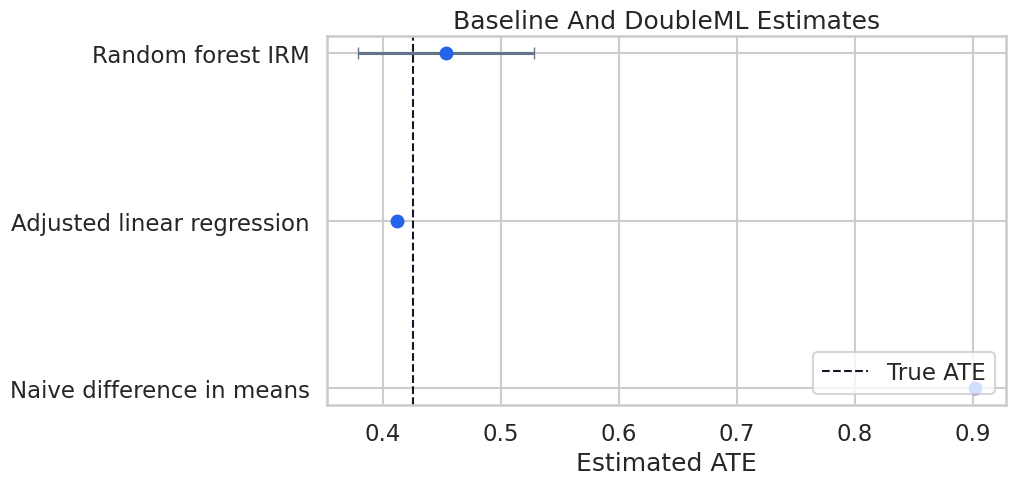

In [8]:
# Build and label the diagnostic visualization for the Main Estimate Plot section.
main_plot_df = pd.concat(
    [
        baseline_estimates.rename(columns={"estimator": "model"})[["model", "estimate", "true_ate"]],
        main_estimate[["model", "estimate", "true_ate", "ci_95_lower", "ci_95_upper"]],
    ],
    ignore_index=True,
)
main_plot_df["ci_95_lower"] = main_plot_df["ci_95_lower"].fillna(main_plot_df["estimate"])
main_plot_df["ci_95_upper"] = main_plot_df["ci_95_upper"].fillna(main_plot_df["estimate"])
main_plot_df["lower_error"] = main_plot_df["estimate"] - main_plot_df["ci_95_lower"]
main_plot_df["upper_error"] = main_plot_df["ci_95_upper"] - main_plot_df["estimate"]

fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.axvline(case_df["true_treatment_effect"].mean(), color="#111827", linestyle="--", linewidth=1.5, label="True ATE")
ax.errorbar(
    x=main_plot_df["estimate"],
    y=np.arange(len(main_plot_df)),
    xerr=[main_plot_df["lower_error"], main_plot_df["upper_error"]],
    fmt="o",
    color="#2563eb",
    ecolor="#64748b",
    capsize=4,
)
ax.set_yticks(np.arange(len(main_plot_df)))
ax.set_yticklabels(main_plot_df["model"])
ax.set_xlabel("Estimated ATE")
ax.set_ylabel("")
ax.set_title("Baseline And DoubleML Estimates")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_main_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The visual comparison shows why end-to-end analysis is useful. A flexible orthogonal estimator should move the answer toward the known causal target when the adjustment set is correct and overlap is reasonable.



### Nuisance Diagnostics

IRM relies on outcome predictions for treated and untreated potential outcomes and a propensity prediction for treatment assignment. The diagnostics below summarize the held-out nuisance performance produced by cross-fitting.

In [9]:
nuisance_diagnostics = pd.DataFrame(
    [
        {"nuisance_model": "ml_g0", "target": "Outcome among untreated", "metric": "RMSE", "value": main_row["ml_g0_rmse"]},
        {"nuisance_model": "ml_g1", "target": "Outcome among treated", "metric": "RMSE", "value": main_row["ml_g1_rmse"]},
        {"nuisance_model": "ml_m", "target": "Propensity", "metric": "Log loss", "value": main_row["ml_m_log_loss"]},
    ]
)

save_table(nuisance_diagnostics, f"{NOTEBOOK_PREFIX}_main_nuisance_diagnostics.csv")
display(nuisance_diagnostics)

,nuisance_model,target,metric,value
0,ml_g0,Outcome among untreated,RMSE,0.979507
1,ml_g1,Outcome among treated,RMSE,0.978074
2,ml_m,Propensity,Log loss,0.471154


These diagnostics are numerical checks. Good nuisance performance supports the estimation workflow, while the identification assumptions still come from the study design.

#### Propensity Overlap Diagnostics

Overlap is central for binary-treatment causal inference. If estimated propensities are extremely close to zero or one, the doubly robust score can become unstable because inverse-propensity terms get large.

In [10]:
propensity_diagnostics = pd.DataFrame(
    [
        {"metric": "min", "value": main_predictions["propensity_hat"].min()},
        {"metric": "p01", "value": main_predictions["propensity_hat"].quantile(0.01)},
        {"metric": "p05", "value": main_predictions["propensity_hat"].quantile(0.05)},
        {"metric": "median", "value": main_predictions["propensity_hat"].median()},
        {"metric": "p95", "value": main_predictions["propensity_hat"].quantile(0.95)},
        {"metric": "p99", "value": main_predictions["propensity_hat"].quantile(0.99)},
        {"metric": "max", "value": main_predictions["propensity_hat"].max()},
        {"metric": "share_below_0.05", "value": (main_predictions["propensity_hat"] < 0.05).mean()},
        {"metric": "share_above_0.95", "value": (main_predictions["propensity_hat"] > 0.95).mean()},
    ]
)

save_table(propensity_diagnostics, f"{NOTEBOOK_PREFIX}_propensity_diagnostics.csv")
display(propensity_diagnostics)


,metric,value
0,min,0.085895
1,p01,0.162704
2,p05,0.214191
3,median,0.461334
4,p95,0.728012
5,p99,0.802605
6,max,0.862869
7,share_below_0.05,0.000000
8,share_above_0.95,0.000000


The estimated propensity distribution has no mass near the extreme boundaries after clipping. That makes the ATE estimate easier to trust numerically than a setting with many near-deterministic treatment assignments.

#### Plot Estimated Propensity Overlap

The histogram compares estimated propensity scores for treated and untreated users. We want enough overlap that both groups appear across the central support.

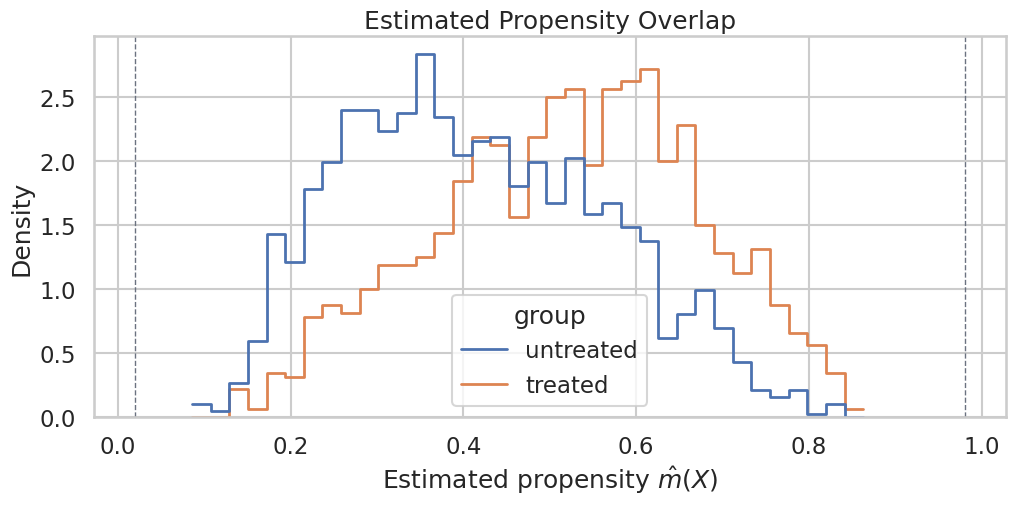

In [11]:
propensity_plot_df = case_df[["onboarding_nudge"]].join(main_predictions[["propensity_hat"]])
propensity_plot_df["group"] = np.where(propensity_plot_df["onboarding_nudge"].eq(1), "treated", "untreated")

fig, ax = plt.subplots(figsize=(10.5, 5.4))
sns.histplot(
    data=propensity_plot_df,
    x="propensity_hat",
    hue="group",
    bins=36,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=2,
    ax=ax,
)
ax.axvline(0.02, color="#6b7280", linestyle="--", linewidth=1, label="clipping threshold")
ax.axvline(0.98, color="#6b7280", linestyle="--", linewidth=1)
ax.set_title("Estimated Propensity Overlap")
ax.set_xlabel(r"Estimated propensity $\hat{m}(X)$")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


The treated and untreated distributions overlap in the middle of the propensity range. If one group appeared only near zero or one, the ATE would rely heavily on extrapolation.

### Compare Learner Families

A complete case study should check whether the main result is a product of one learner choice. We compare three nuisance-model families: a linear/logistic baseline, random forests, and histogram gradient boosting.

In [12]:
# Fit or evaluate the model objects used in the Compare Learner Families section.
learner_specs = {
    "Linear-logistic IRM": {
        "ml_g": make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=RANDOM_SEED, max_iter=10_000)),
        "ml_m": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2_000, solver="lbfgs")),
    },
    "Random forest IRM": {
        "ml_g": main_outcome_learner,
        "ml_m": main_propensity_learner,
    },
    "Histogram gradient boosting IRM": {
        "ml_g": HistGradientBoostingRegressor(max_iter=180, learning_rate=0.05, min_samples_leaf=25, random_state=RANDOM_SEED),
        "ml_m": HistGradientBoostingClassifier(max_iter=180, learning_rate=0.05, min_samples_leaf=25, random_state=RANDOM_SEED + 2),
    },
}

learner_rows = []
learner_models = {}
learner_predictions = {}
for label, spec in learner_specs.items():
    model, row, preds = fit_irm(
        case_df,
        x_cols=x_cols,
        learner_g=spec["ml_g"],
        learner_m=spec["ml_m"],
        label=label,
    )
    learner_models[label] = model
    learner_predictions[label] = preds
    learner_rows.append(row)

learner_comparison = pd.DataFrame(learner_rows).sort_values("absolute_error")
save_table(learner_comparison, f"{NOTEBOOK_PREFIX}_learner_family_comparison.csv")
display(learner_comparison)


,model,estimate,std_error,ci_95_lower,ci_95_upper,true_ate,absolute_error,ml_g0_rmse,ml_g1_rmse,ml_m_log_loss,propensity_min,propensity_p05,propensity_median,propensity_p95,propensity_max
0,Linear-logistic IRM,0.405067,0.034674,0.337107,0.473028,0.425708,0.020640,0.894994,0.898052,0.465686,0.046837,0.176967,0.457112,0.771369,0.951704
1,Random forest IRM,0.458212,0.037880,0.383968,0.532456,0.425708,0.032504,0.979138,0.982657,0.470997,0.096164,0.213821,0.460432,0.731480,0.872942
2,Histogram gradient boosting IRM,0.378412,0.042708,0.294706,0.462117,0.425708,0.047296,0.961284,0.962784,0.493158,0.024444,0.098264,0.450553,0.850580,0.966211


The learner comparison should be read as robustness evidence. If all reasonable learner families tell a similar story, the result is less dependent on a single modeling choice. If they diverge, the report should slow down and explain why.



#### Plot Learner Family Estimates

The plot below compares point estimates and confidence intervals across nuisance learner choices. The true ATE line is available only because this is a teaching simulation.

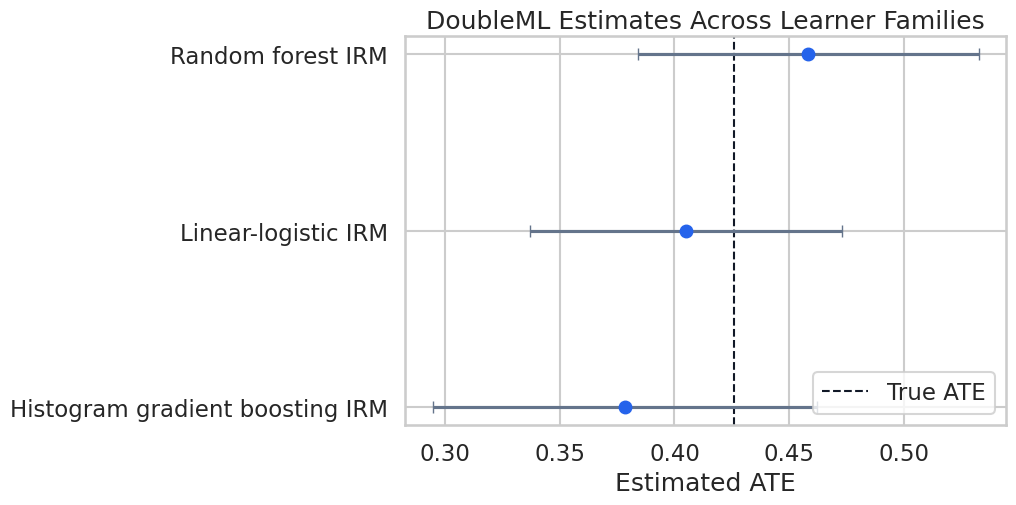

In [13]:
learner_plot = learner_comparison.sort_values("estimate").copy()
learner_plot["lower_error"] = learner_plot["estimate"] - learner_plot["ci_95_lower"]
learner_plot["upper_error"] = learner_plot["ci_95_upper"] - learner_plot["estimate"]

fig, ax = plt.subplots(figsize=(10.5, 5.4))
ax.axvline(case_df["true_treatment_effect"].mean(), color="#111827", linestyle="--", linewidth=1.5, label="True ATE")
ax.errorbar(
    x=learner_plot["estimate"],
    y=np.arange(len(learner_plot)),
    xerr=[learner_plot["lower_error"], learner_plot["upper_error"]],
    fmt="o",
    color="#2563eb",
    ecolor="#64748b",
    capsize=4,
)
ax.set_yticks(np.arange(len(learner_plot)))
ax.set_yticklabels(learner_plot["model"])
ax.set_xlabel("Estimated ATE")
ax.set_ylabel("")
ax.set_title("DoubleML Estimates Across Learner Families")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_learner_family_estimates.png", dpi=160, bbox_inches="tight")
plt.show()


The estimates are close enough to support a coherent main story. The learner table still belongs in the final report because it shows the result is not simply a random-forest output.




#### Doubly Robust Signal for Segment Diagnostics

The doubly robust signal is useful for exploratory subgroup summaries. Here we use it to ask whether high-intent users appear to benefit more from the nudge. This is a diagnostic use of the score signal, not a replacement for a formal policy-learning or GATE analysis.

In [14]:
case_df_with_signal = case_df.copy()
case_df_with_signal["dr_signal"] = doubly_robust_signal(case_df, main_predictions)

segment_summary = (
    case_df_with_signal.groupby("intent_segment", observed=True)
    .agg(
        n=("dr_signal", "size"),
        dr_ate=("dr_signal", "mean"),
        dr_se=("dr_signal", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        true_segment_ate=("true_treatment_effect", "mean"),
        treatment_rate=("onboarding_nudge", "mean"),
    )
    .reset_index()
)
segment_summary["ci_95_lower"] = segment_summary["dr_ate"] - 1.96 * segment_summary["dr_se"]
segment_summary["ci_95_upper"] = segment_summary["dr_ate"] + 1.96 * segment_summary["dr_se"]

save_table(segment_summary, f"{NOTEBOOK_PREFIX}_segment_dr_signal_summary.csv")
display(segment_summary)


,intent_segment,n,dr_ate,dr_se,true_segment_ate,treatment_rate,ci_95_lower,ci_95_upper
0,low_intent,1067,0.296084,0.071644,0.272389,0.303655,0.155661,0.436506
1,mid_intent,1066,0.507545,0.060465,0.425631,0.462477,0.389034,0.626056
2,high_intent,1067,0.557834,0.064187,0.579102,0.623243,0.432028,0.683640


The segment summary should move in the same direction as the known heterogeneous effect pattern. In real data, this would be a hypothesis-generating diagnostic unless accompanied by a formal heterogeneity design.



#### Plot Segment Effects

The segment plot compares doubly robust subgroup means with the oracle segment effects from the simulator. The oracle points are included only for learning.

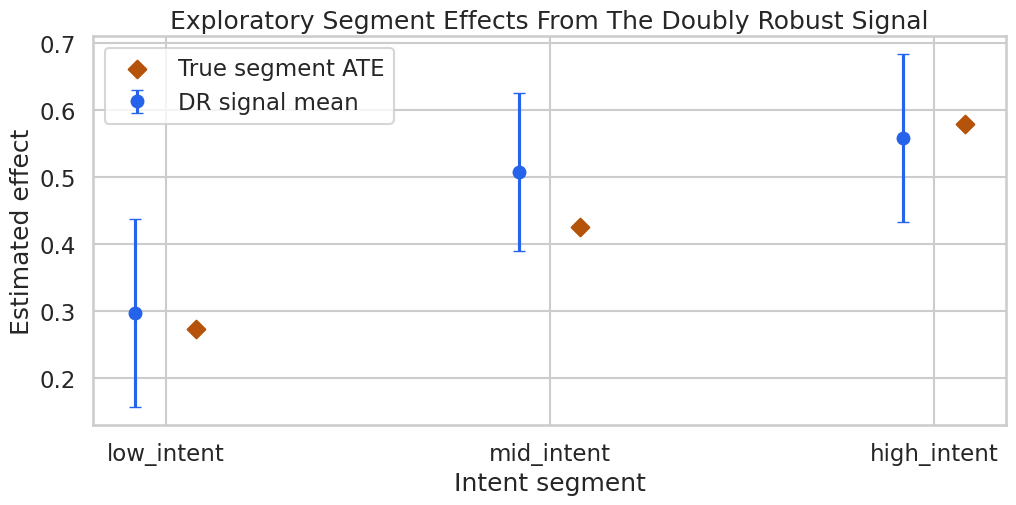

In [15]:
# Build and label the diagnostic visualization for the Plot Segment Effects section.
fig, ax = plt.subplots(figsize=(10.5, 5.4))
positions = np.arange(len(segment_summary))
ax.errorbar(
    positions - 0.08,
    segment_summary["dr_ate"],
    yerr=1.96 * segment_summary["dr_se"],
    fmt="o",
    color="#2563eb",
    capsize=4,
    label="DR signal mean",
)
ax.scatter(
    positions + 0.08,
    segment_summary["true_segment_ate"],
    color="#b45309",
    marker="D",
    label="True segment ATE",
)
ax.set_xticks(positions)
ax.set_xticklabels(segment_summary["intent_segment"])
ax.set_ylabel("Estimated effect")
ax.set_xlabel("Intent segment")
ax.set_title("Exploratory Segment Effects From The Doubly Robust Signal")
ax.legend(loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_segment_effects.png", dpi=160, bbox_inches="tight")
plt.show()


The high-intent segment shows a larger effect, matching the way the example data were generated. The important reporting habit is to label this as subgroup evidence, not as an automatically deployable targeting rule.



#### Sample-Split Stability

Cross-fitting uses random folds. A single split can occasionally be lucky or unlucky. We refit the main random-forest specification over several deterministic fold seeds to check whether the estimate is stable.

In [16]:
# Fit or evaluate the model objects used in the Sample-Split Stability section.
stability_rows = []
stability_seeds = list(range(RANDOM_SEED, RANDOM_SEED + 8))

stability_outcome_learner = RandomForestRegressor(
    n_estimators=140,
    min_samples_leaf=14,
    max_features="sqrt",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
stability_propensity_learner = RandomForestClassifier(
    n_estimators=140,
    min_samples_leaf=14,
    max_features="sqrt",
    random_state=RANDOM_SEED + 1,
    n_jobs=-1,
)

for seed in stability_seeds:
    sample_splits = make_kfold_splits(len(case_df), seed=seed, n_splits=5)
    model, row, _ = fit_irm(
        case_df,
        x_cols=x_cols,
        learner_g=stability_outcome_learner,
        learner_m=stability_propensity_learner,
        label=f"split_seed_{seed}",
        sample_splits=sample_splits,
    )
    row["split_seed"] = seed
    stability_rows.append(row)

split_stability = pd.DataFrame(stability_rows)
split_stability_summary = pd.DataFrame(
    [
        {
            "n_repetitions": len(split_stability),
            "mean_estimate": split_stability["estimate"].mean(),
            "sd_estimate": split_stability["estimate"].std(ddof=1),
            "min_estimate": split_stability["estimate"].min(),
            "max_estimate": split_stability["estimate"].max(),
            "true_ate": case_df["true_treatment_effect"].mean(),
        }
    ]
)

save_table(split_stability, f"{NOTEBOOK_PREFIX}_sample_split_stability.csv")
save_table(split_stability_summary, f"{NOTEBOOK_PREFIX}_sample_split_stability_summary.csv")
display(split_stability_summary)


,n_repetitions,mean_estimate,sd_estimate,min_estimate,max_estimate,true_ate
0,8,0.462021,0.006578,0.450427,0.469819,0.425708


The repeated-split standard deviation is a practical stability check. If fold randomness changed the conclusion, the final report would need to say so and rely on repeated cross-fitting or a more stable design.

#### Plot Sample-Split Stability

This plot shows the repeated estimates against the main estimate and true ATE. It is a compact way to communicate whether cross-fitting randomness matters materially.

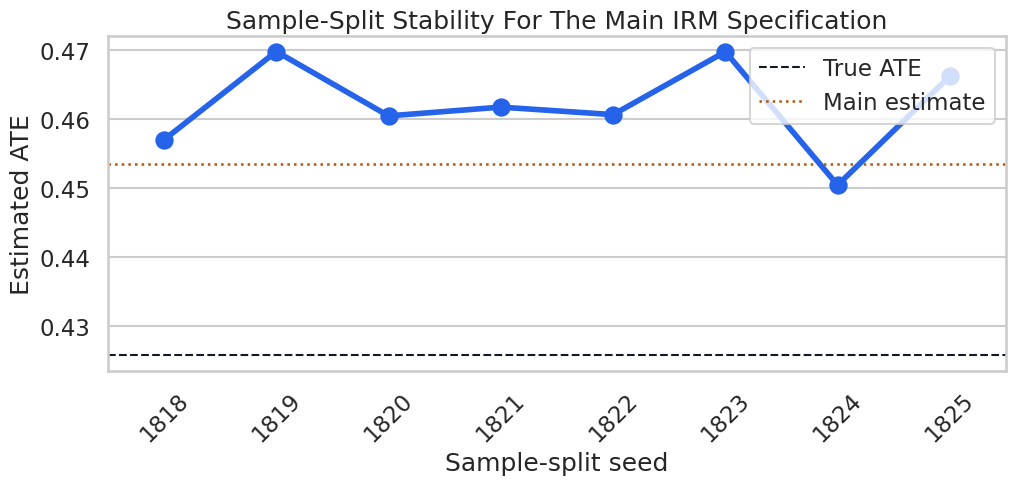

In [17]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.axhline(case_df["true_treatment_effect"].mean(), color="#111827", linestyle="--", linewidth=1.5, label="True ATE")
ax.axhline(main_row["estimate"], color="#b45309", linestyle=":", linewidth=1.8, label="Main estimate")
sns.pointplot(
    data=split_stability,
    x="split_seed",
    y="estimate",
    color="#2563eb",
    errorbar=None,
    ax=ax,
)
ax.set_title("Sample-Split Stability For The Main IRM Specification")
ax.set_xlabel("Sample-split seed")
ax.set_ylabel("Estimated ATE")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sample_split_stability.png", dpi=160, bbox_inches="tight")
plt.show()


The repeated estimates cluster around the same value. This supports the numerical stability of the main estimate under alternative fold assignments.

The causal implication is indirect but important: these diagnostics tell us whether the modeling stage is stable enough to support the causal estimate.
<!-- result-implication-expanded -->


#### Sensitivity Analysis for Hidden Confounding

The final statistical check uses DoubleML's sensitivity analysis. The parameters `cf_y` and `cf_d` describe the strength of an unobserved confounder in the outcome and treatment equations. The parameter `rho` controls the direction of confounding. These are not discovered from the data; they are stress-test settings.

In [18]:
# Define reusable helpers for the Sensitivity Analysis For Hidden Confounding section.
def extract_sensitivity_row(model, scenario, cf_y, cf_d, rho):
    """
    Idea: Extract the sensitivity row from a fitted object or result table so it can be reported consistently.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by the diagnostic.
    scenario : str
        Scenario label describing the data-generating or diagnostic condition.
    cf_y : object
        Counterfactual or residualized outcome component used by the score.
    cf_d : object
        Counterfactual or residualized treatment component used by the score.
    rho : object
        Sensitivity or correlation parameter used in the scenario.
    
    Returns
    -------
    dict[str, float]
        Sensitivity-analysis summary row with robustness values and adjusted intervals.
    """
    params = model.sensitivity_params
    return {
        "scenario": scenario,
        "cf_y": cf_y,
        "cf_d": cf_d,
        "rho": rho,
        "theta_lower": float(params["theta"]["lower"][0]),
        "theta": float(model.coef[0]),
        "theta_upper": float(params["theta"]["upper"][0]),
        "ci_lower": float(params["ci"]["lower"][0]),
        "ci_upper": float(params["ci"]["upper"][0]),
        "rv_percent": float(params["rv"][0] * 100),
        "rva_percent": float(params["rva"][0] * 100),
    }

sensitivity_specs = [
    ("mild", 0.01, 0.01, 1.0),
    ("moderate", 0.03, 0.03, 1.0),
    ("strong", 0.06, 0.06, 1.0),
]

sensitivity_rows = []
for scenario, cf_y, cf_d, rho in sensitivity_specs:
    main_irm.sensitivity_analysis(cf_y=cf_y, cf_d=cf_d, rho=rho, level=0.95, null_hypothesis=0.0)
    sensitivity_rows.append(extract_sensitivity_row(main_irm, scenario, cf_y, cf_d, rho))

sensitivity_summary = pd.DataFrame(sensitivity_rows)
save_table(sensitivity_summary, f"{NOTEBOOK_PREFIX}_sensitivity_summary.csv")
display(sensitivity_summary)

# Restore the moderate scenario as the active sensitivity setting for anyone inspecting the model object later.
main_irm.sensitivity_analysis(cf_y=0.03, cf_d=0.03, rho=1.0, level=0.95, null_hypothesis=0.0)


,scenario,cf_y,cf_d,rho,theta_lower,theta,theta_upper,ci_lower,ci_upper,rv_percent,rva_percent
0,mild,0.01,0.01,1.0,0.432474,0.453473,0.474473,0.369918,0.536913,19.475467,16.972087
1,moderate,0.03,0.03,1.0,0.389829,0.453473,0.517118,0.327137,0.579459,19.475467,16.972087
2,strong,0.06,0.06,1.0,0.324169,0.453473,0.582778,0.261234,0.645000,19.475467,16.972087


The sensitivity table asks how much the estimate could move under increasingly strong hidden-confounding scenarios. It does not prove that hidden confounding is absent. It makes the remaining assumption visible.

#### Plot Sensitivity Bounds

The sensitivity plot shows how the lower and upper treatment-effect bounds change as the hidden-confounding stress test gets stronger.

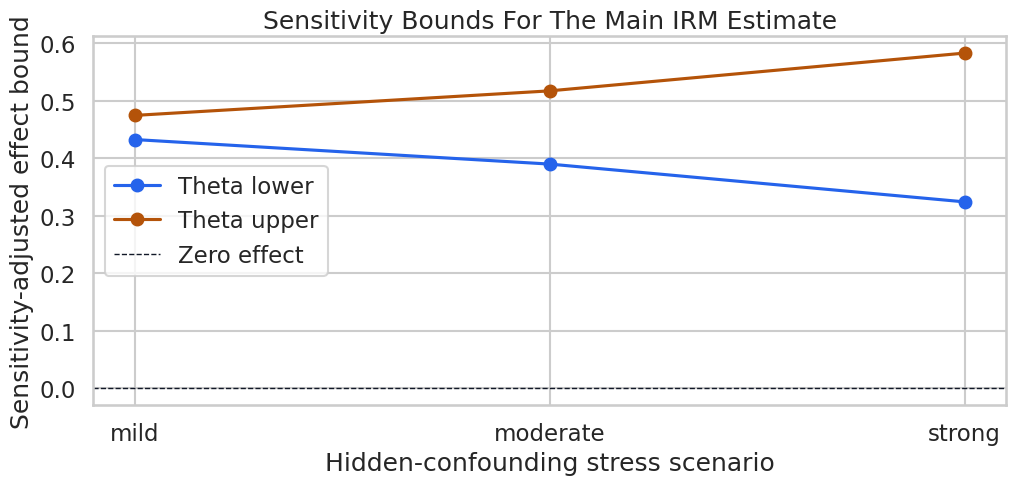

In [19]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
positions = np.arange(len(sensitivity_summary))
ax.plot(positions, sensitivity_summary["theta_lower"], marker="o", color="#2563eb", label="Theta lower")
ax.plot(positions, sensitivity_summary["theta_upper"], marker="o", color="#b45309", label="Theta upper")
ax.axhline(0, color="#111827", linestyle="--", linewidth=1, label="Zero effect")
ax.set_xticks(positions)
ax.set_xticklabels(sensitivity_summary["scenario"])
ax.set_ylabel("Sensitivity-adjusted effect bound")
ax.set_xlabel("Hidden-confounding stress scenario")
ax.set_title("Sensitivity Bounds For The Main IRM Estimate")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sensitivity_bounds.png", dpi=160, bbox_inches="tight")
plt.show()


The sensitivity bounds communicate the main limitation of observational analysis: the result can be numerically precise and still depend on an untestable adjustment assumption.

#### Final Evidence Scorecard

The scorecard pulls together the pieces a reviewer should see before trusting the result. It includes design, overlap, nuisance quality, learner robustness, split stability, heterogeneity, and sensitivity.

In [20]:
# Save the artifacts produced by the Final Evidence Scorecard section.
evidence_scorecard = pd.DataFrame(
    [
        {
            "evidence_area": "Design",
            "finding": "Only pre-treatment controls are used in the main feature set.",
            "status": "documented",
        },
        {
            "evidence_area": "Main estimate",
            "finding": f"Main IRM ATE is {main_row['estimate']:.3f} with 95% CI [{main_row['ci_95_lower']:.3f}, {main_row['ci_95_upper']:.3f}].",
            "status": "estimated",
        },
        {
            "evidence_area": "Overlap",
            "finding": f"Estimated propensity p05={main_row['propensity_p05']:.3f}, p95={main_row['propensity_p95']:.3f}.",
            "status": "checked",
        },
        {
            "evidence_area": "Learner robustness",
            "finding": f"Learner-family estimates range from {learner_comparison['estimate'].min():.3f} to {learner_comparison['estimate'].max():.3f}.",
            "status": "checked",
        },
        {
            "evidence_area": "Sample splitting",
            "finding": f"Repeated split SD is {split_stability_summary.loc[0, 'sd_estimate']:.4f}.",
            "status": "checked",
        },
        {
            "evidence_area": "Heterogeneity",
            "finding": "DR signal summaries suggest larger effects for higher-intent users.",
            "status": "exploratory",
        },
        {
            "evidence_area": "Sensitivity",
            "finding": "Sensitivity bounds are reported for mild, moderate, and strong hidden-confounding scenarios.",
            "status": "stress tested",
        },
        {
            "evidence_area": "Limitations",
            "finding": "Unmeasured confounding, measurement error, and deployment interference remain design risks.",
            "status": "must report",
        },
    ]
)

save_table(evidence_scorecard, f"{NOTEBOOK_PREFIX}_evidence_scorecard.csv")
display(evidence_scorecard)


,evidence_area,finding,status
0,Design,Only pre-treatment controls are used in the main feature set.,documented
1,Main estimate,"Main IRM ATE is 0.453 with 95% CI [0.379, 0.528].",estimated
2,Overlap,"Estimated propensity p05=0.214, p95=0.728.",checked
3,Learner robustness,Learner-family estimates range from 0.378 to 0.458.,checked
4,Sample splitting,Repeated split SD is 0.0066.,checked
5,Heterogeneity,DR signal summaries suggest larger effects for higher-intent users.,exploratory
6,Sensitivity,"Sensitivity bounds are reported for mild, moderate, and strong hidden-confounding scenarios.",stress tested
7,Limitations,"Unmeasured confounding, measurement error, and deployment interference remain design risks.",must report


The scorecard is a compact review object. It is the bridge between a technical notebook and a reader who wants to know whether the analysis is credible.




## Reporting and Takeaways

### Write the Final Case Study Report

The report template below is written as if this were the final deliverable. It includes the causal question, estimator, main estimate, diagnostics, sensitivity, subgroup findings, and limitations.

In [21]:
report_text = rf"""# End-To-End DoubleML Case Study Report

## Causal Question
Estimate the average effect of receiving a guided onboarding nudge on next-period user value.

## Estimand
The target estimand is the average treatment effect:

$$
\theta_0 = \mathbb{{E}}[Y(1) - Y(0)].
$$

## Identification Assumptions
The analysis assumes conditional exchangeability given the documented pre-treatment controls, overlap between treated and untreated users, stable treatment definition, and no interference across users.

## Main DoubleML Specification
- Estimator: `DoubleMLIRM`
- Score: ATE
- Outcome learner: random forest regressor
- Propensity learner: random forest classifier
- Cross-fitting: 5 folds
- Propensity clipping threshold: 0.02

## Main Estimate
- Estimated ATE: {main_row['estimate']:.4f}
- Standard error: {main_row['std_error']:.4f}
- 95% confidence interval: [{main_row['ci_95_lower']:.4f}, {main_row['ci_95_upper']:.4f}]
- Known true ATE in this teaching simulation: {main_row['true_ate']:.4f}

## Diagnostics
- Estimated propensity p05 / p95: {main_row['propensity_p05']:.4f} / {main_row['propensity_p95']:.4f}
- Outcome RMSE under control model: {main_row['ml_g0_rmse']:.4f}
- Outcome RMSE under treated model: {main_row['ml_g1_rmse']:.4f}
- Propensity log loss: {main_row['ml_m_log_loss']:.4f}
- Sample-split estimate SD: {split_stability_summary.loc[0, 'sd_estimate']:.4f}

## Heterogeneity
The doubly robust signal suggests larger effects for higher-intent users. Treat this as subgroup evidence, not as a fully validated targeting policy.

## Sensitivity
Sensitivity bounds are saved for mild, moderate, and strong hidden-confounding scenarios. These stress tests do not remove hidden-confounding risk; they describe how the estimate would move under specified scenarios.

## Limitations
The analysis remains observational. It can be threatened by missing confounders, bad measurement, outcome leakage, violations of overlap, interference, or changes in the treatment definition.

## Artifact Paths
- Data: `{DATASET_DIR / f'{NOTEBOOK_PREFIX}_end_to_end_case_study_data.csv'}`
- Main estimate: `{TABLE_DIR / f'{NOTEBOOK_PREFIX}_main_irm_estimate.csv'}`
- Learner comparison: `{TABLE_DIR / f'{NOTEBOOK_PREFIX}_learner_family_comparison.csv'}`
- Segment summary: `{TABLE_DIR / f'{NOTEBOOK_PREFIX}_segment_dr_signal_summary.csv'}`
- Sensitivity summary: `{TABLE_DIR / f'{NOTEBOOK_PREFIX}_sensitivity_summary.csv'}`
- Evidence scorecard: `{TABLE_DIR / f'{NOTEBOOK_PREFIX}_evidence_scorecard.csv'}`
"""

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_end_to_end_case_study_report.md"
report_path.write_text(report_text)
print(f"Wrote report to: {report_path}")


Wrote report to: /home/apex/Documents/portfolio/notebooks/tutorials/doubleml/outputs/reports/18_end_to_end_case_study_report.md


The report is short on purpose. A final case-study report should not reproduce every notebook cell. It should tell a clear story and point to the outputs that support that story.


The manifest is the table of contents for the case study outputs. It also makes the notebook easier to grade, review, or convert into a portfolio writeup.



### Tutorial Wrap-Up

This case study pulls the DoubleML tutorial series together. The workflow is intentionally repeatable:

- Define the causal question and target estimand.
- Document variable timing and exclude invalid controls.
- Choose the DoubleML class that matches the treatment and data structure.
- Fit flexible nuisance models with cross-fitting.
- Report uncertainty, overlap, nuisance diagnostics, learner robustness, and split stability.
- Treat subgroup findings as exploratory unless the heterogeneity design is formal.
- Use sensitivity analysis to describe, not erase, hidden-confounding risk.
- End with a concise report and reviewable outputs.

The main lesson is that DoubleML is a disciplined estimation framework. The quality of the answer still depends on the quality of the causal design.
